# 安徽农户持续种粮调研：公开数据分析与结果复核

本 Notebook 配套研究报告《把地种好，把日子过稳——稳定承包背景下安徽农户持续种粮的约束结构》，完整读取公开仓库中的聚合分析结果与图表数据，复核主要统计口径并重绘核心结果。

**数据边界：**公开仓库不含逐行原始答卷、逐行清洗主表或可回溯到个体的记录。因此，本 Notebook 能复核公开结果、比例计算、图表数据和文件间一致性，但不能在没有受控微观数据的情况下重新估计全部个体层模型或重新执行聚类分配。

**证据定位：**2025 年农户数据承担家庭经营与撂荒关系的主实证；2026 年农户和村级数据提供政策认知、合同、托管服务、未来安排与村级治理的并列描述性证据。不同指标采用各自有效分母。

## 1. 运行环境与数据路径

Notebook 可从仓库根目录或 `notebooks/` 目录执行。所有输入均来自 `02_公开数据/`，不会读取公开仓库之外的文件。

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

candidates = [Path.cwd(), Path.cwd().parent, Path.cwd() / "public-release"]
ROOT = next(
    (path.resolve() for path in candidates if (path / "02_公开数据").is_dir()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("未找到公开仓库根目录及 02_公开数据 目录。")

DATA_ROOT = ROOT / "02_公开数据"
RESULT_DIR = DATA_ROOT / "聚合分析结果"
FIGURE_DATA_DIR = DATA_ROOT / "图表数据"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["font.sans-serif"] = [
    "Noto Sans CJK SC", "Microsoft YaHei", "SimHei",
    "Arial Unicode MS", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(20260914)

print("公开仓库根目录：已定位")
print(f"Python：{platform.python_version()}")
print(f"pandas：{pd.__version__}；NumPy：{np.__version__}")

公开仓库根目录：已定位
Python：3.11.16
pandas：3.0.5；NumPy：2.4.6


## 2. 公开数据清单、粒度与直接标识检查

下表列出所有公开 CSV/JSON 数据。这里的“行数”是汇总指标、模型项、情景网格点或画像类别的数量，不代表公开了对应数量的受访者记录。

In [2]:
data_files = sorted(
    path for path in DATA_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in {".csv", ".json"}
)

inventory = []
for path in data_files:
    relative = path.relative_to(ROOT).as_posix()
    if path.suffix.lower() == ".csv":
        frame = pd.read_csv(path)
        inventory.append(
            {"文件": relative, "格式": "CSV", "行数": len(frame), "字段数": len(frame.columns)}
        )
    else:
        value = json.loads(path.read_text(encoding="utf-8-sig"))
        inventory.append(
            {
                "文件": relative,
                "格式": "JSON",
                "行数": len(value) if hasattr(value, "__len__") else 1,
                "字段数": len(value) if isinstance(value, dict) else np.nan,
            }
        )

inventory_df = pd.DataFrame(inventory)
display(inventory_df)
print(f"公开研究数据文件：{len(data_files)} 个")

,文件,格式,行数,字段数
0,02_公开数据/图表数据/fig1-2_ah_urban_rural_income.csv,CSV,5,3
1,02_公开数据/图表数据/fig4-1_land_status.csv,CSV,4,3
2,02_公开数据/图表数据/fig4-2_labor_fallow.csv,CSV,3,3
3,02_公开数据/图表数据/fig4-3_logit_or.csv,CSV,6,5
4,02_公开数据/图表数据/fig4-4_area_disaster_prediction.csv,CSV,160,3
5,02_公开数据/图表数据/fig5-2_profile_heatmap.csv,CSV,4,8
6,02_公开数据/图表数据/fig5-3_profile_metrics.csv,CSV,4,16
7,02_公开数据/图表数据/fig6-2_policy_future.csv,CSV,6,8
8,02_公开数据/图表数据/fig6-3_contract_service_constrain...,CSV,6,8
9,02_公开数据/图表数据/fig6-4_village_governance.csv,CSV,6,8


公开研究数据文件：24 个


In [3]:
risky_field_parts = {
    "姓名", "手机号", "联系电话", "身份证", "邮箱", "电子邮件",
    "详细地址", "家庭住址", "答卷id", "受访者编号",
    "respondent_id", "phone", "mobile", "email", "id_card",
    "identity_number", "ip_address", "openid", "unionid",
}
value_patterns = {
    "中国大陆手机号": re.compile(r"(?<![\d./])1[3-9]\d{9}(?![\d./])"),
    "电子邮箱": re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"),
    "IPv4": re.compile(
        r"(?<![\d.])(?:25[0-5]|2[0-4]\d|1?\d?\d)"
        r"(?:\.(?:25[0-5]|2[0-4]\d|1?\d?\d)){3}(?![\d.])"
    ),
    "微信ID": re.compile(r"(?i)\bwxid_[a-z0-9]+\b"),
    "Windows个人路径": re.compile(r"(?i)\b[A-Z]:\\"),
    "Linux个人路径": re.compile(r"/home/[A-Za-z0-9._-]+/"),
}

risky_fields = []
direct_value_hits = []
for path in data_files:
    relative = path.relative_to(ROOT).as_posix()
    text = path.read_text(encoding="utf-8-sig")
    if path.suffix.lower() == ".csv":
        fields = list(pd.read_csv(path, nrows=0).columns)
    else:
        value = json.loads(text)
        fields = []
        stack = [value]
        while stack:
            item = stack.pop()
            if isinstance(item, dict):
                fields.extend(map(str, item.keys()))
                stack.extend(item.values())
            elif isinstance(item, list):
                stack.extend(item)
    for field in fields:
        normalized = re.sub(r"[\s-]+", "_", field.casefold())
        if any(part in normalized for part in risky_field_parts):
            risky_fields.append((relative, field))
    for label, pattern in value_patterns.items():
        if pattern.search(text):
            direct_value_hits.append((relative, label))

assert not risky_fields, f"发现高风险字段：{risky_fields}"
assert not direct_value_hits, f"发现直接标识模式：{direct_value_hits}"
print("直接标识检查：通过")
print("高风险字段：0；手机号/邮箱/IP/微信ID/个人路径模式：0")

直接标识检查：通过
高风险字段：0；手机号/邮箱/IP/微信ID/个人路径模式：0


## 3. 2025 年主实证：土地状态与劳动力分组

2025 年数据是报告的主实证。公开结果显示总体撂荒比例，以及转入、转出和托管等经营状态。各指标的有效分母可能不同。

,state,n,percent
0,存在撂荒,2079,8.23%
1,有土地转入,2064,43.90%
2,有土地转出,2064,37.35%
3,有托管面积,2066,42.55%


,group,n,fallow_percent
0,0—2人,1076,8.27%
1,3人,601,8.15%
2,4人及以上,400,8.00%


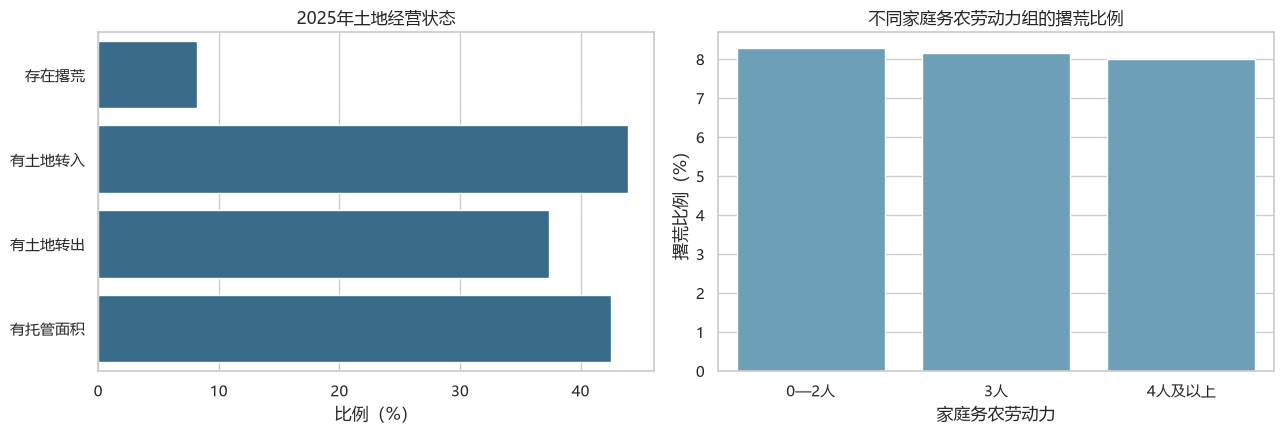

In [4]:
land_status = pd.read_csv(RESULT_DIR / "2025年土地状态统计.csv")
labor_groups = pd.read_csv(RESULT_DIR / "2025年撂荒分组统计.csv")
display(land_status.style.format({"percent": "{:.2f}%"}))
display(labor_groups.style.format({"fallow_percent": "{:.2f}%"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=land_status, x="percent", y="state", color="#2A6F97", ax=axes[0])
axes[0].set(title="2025年土地经营状态", xlabel="比例（%）", ylabel="")
sns.barplot(data=labor_groups, x="group", y="fallow_percent", color="#61A5C2", ax=axes[1])
axes[1].set(title="不同家庭务农劳动力组的撂荒比例", xlabel="家庭务农劳动力", ylabel="撂荒比例（%）")
plt.tight_layout()
plt.show()

## 4. 2025 年撂荒模型结果

公开表提供模型系数、优势比（OR）、置信区间和 Bootstrap 符号检验结果。由于微观数据未公开，这里复核已发布的模型输出并绘制森林图，不重新拟合模型。

,term,odds_ratio,ci_low_or,ci_high_or,bootstrap_sign_p,n,置信区间是否跨1
1,家庭务农劳动力（每增加1人）,1.013,0.868,1.172,0.8956,2055,True
2,ln(1+经营面积),0.825,0.672,0.963,0.0180,2055,False
3,地块数（每增加1块）,1.002,0.999,1.007,0.1089,2055,True
4,受灾（是/否）,1.940,1.381,2.656,0.0010,2055,False
5,ln(1+农业收入),1.006,0.865,1.138,0.9445,2055,True
6,ln(1+非农收入),1.030,0.918,1.155,0.5907,2055,True


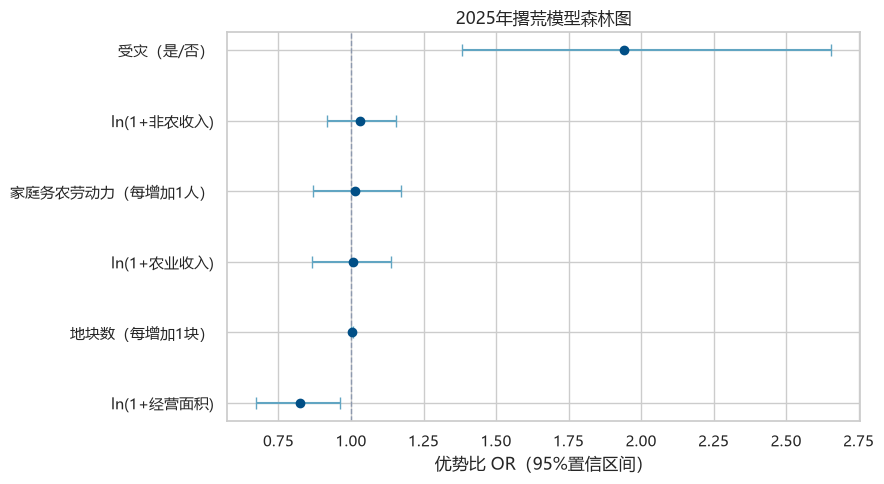

In [5]:
fallow_model = pd.read_csv(RESULT_DIR / "2025年撂荒模型结果.csv")
model_view = fallow_model.loc[fallow_model["term"] != "截距"].copy()
model_view["置信区间是否跨1"] = ~(
    (model_view["ci_low_or"] > 1) | (model_view["ci_high_or"] < 1)
)
display(
    model_view[
        ["term", "odds_ratio", "ci_low_or", "ci_high_or", "bootstrap_sign_p", "n", "置信区间是否跨1"]
    ].style.format(
        {
            "odds_ratio": "{:.3f}", "ci_low_or": "{:.3f}",
            "ci_high_or": "{:.3f}", "bootstrap_sign_p": "{:.4f}",
        }
    )
)

ordered = model_view.sort_values("odds_ratio")
y = np.arange(len(ordered))
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    ordered["odds_ratio"], y,
    xerr=[ordered["odds_ratio"] - ordered["ci_low_or"], ordered["ci_high_or"] - ordered["odds_ratio"]],
    fmt="o", color="#014F86", ecolor="#61A5C2", capsize=4,
)
ax.axvline(1, color="#8D99AE", linestyle="--", linewidth=1)
ax.set(yticks=y, yticklabels=ordered["term"], xlabel="优势比 OR（95%置信区间）", title="2025年撂荒模型森林图")
plt.tight_layout()
plt.show()

## 5. 经营面积、受灾与预测撂荒比例

下图直接依据公开的预测情景网格绘制，用于展示模型条件下的关联结构。预测曲线不是因果效应，也不是对某个具体农户的预测。

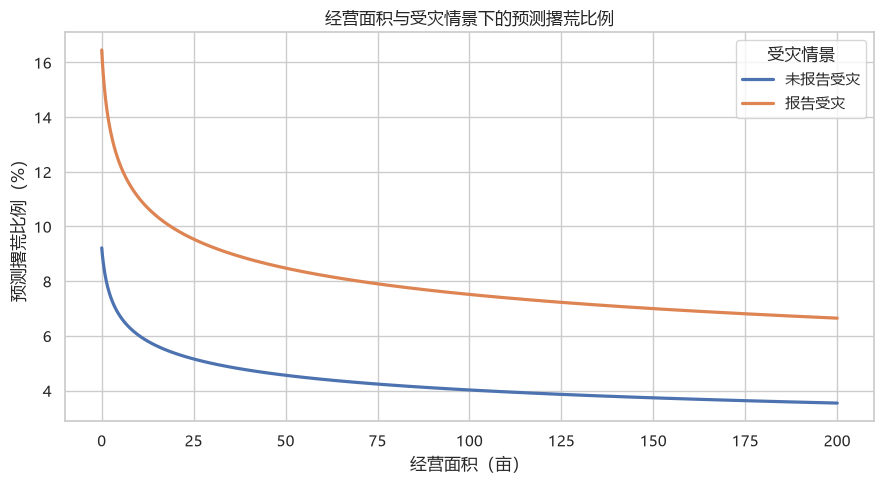

In [6]:
prediction = pd.read_csv(RESULT_DIR / "2025年预测情景网格.csv")
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=prediction,
    x="operated_area_mu", y="predicted_fallow_percent",
    hue="disaster", linewidth=2.3, ax=ax,
)
ax.set(xlabel="经营面积（亩）", ylabel="预测撂荒比例（%）", title="经营面积与受灾情景下的预测撂荒比例")
ax.legend(title="受灾情景")
plt.tight_layout()
plt.show()

## 6. 2025 年敏感性检验

比较主模型、质量标记排除和替代面积口径。这里保留每种口径的样本数与关键优势比，避免把不同分析分母混为同一总体。

,scenario,n,fallow_percent,labor_or,area_or,disaster_or,status
0,主模型：填报经营面积,2055,8.03%,1.013,0.825,1.940,PASS
1,排除任一2025质量标记,980,5.92%,1.046,0.912,1.421,PASS
2,排除680条面积恒等式异常,1377,7.04%,1.035,0.669,1.549,PASS
3,替代面积：承包+转入-转出,2054,8.03%,0.999,0.869,1.931,PASS
4,替代面积：承包+转入-转出+托管,2054,8.03%,0.997,0.848,1.932,PASS


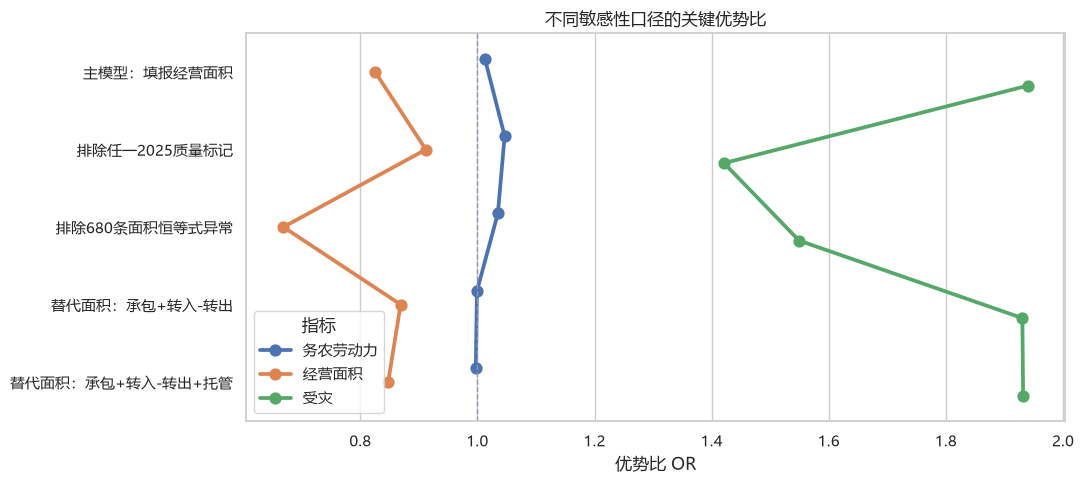

In [7]:
sensitivity = pd.read_csv(RESULT_DIR / "2025年敏感性检验.csv")
display(sensitivity.style.format({"fallow_percent": "{:.2f}%", "labor_or": "{:.3f}", "area_or": "{:.3f}", "disaster_or": "{:.3f}"}))

sensitivity_long = sensitivity.melt(
    id_vars=["scenario", "n"],
    value_vars=["labor_or", "area_or", "disaster_or"],
    var_name="指标", value_name="OR",
)
label_map = {"labor_or": "务农劳动力", "area_or": "经营面积", "disaster_or": "受灾"}
sensitivity_long["指标"] = sensitivity_long["指标"].map(label_map)
fig, ax = plt.subplots(figsize=(11, 5))
sns.pointplot(data=sensitivity_long, x="OR", y="scenario", hue="指标", dodge=0.35, ax=ax)
ax.axvline(1, color="#8D99AE", linestyle="--", linewidth=1)
ax.set(xlabel="优势比 OR", ylabel="", title="不同敏感性口径的关键优势比")
plt.tight_layout()
plt.show()

## 7. 2025 年经营画像

公开画像表提供四类画像的聚合特征和群组规模。由于个体分配未公开，本节只展示群组层汇总，不尝试识别或还原任何受访者。

,profile,n,share_percent,labor,operated_area,grain_area,fallow_percent,managed_percent,transfer_out_percent,transfer_in_percent
0,稳定自种型,1590,77.45,2.00,5.00,4.00,7.86,34.97,30.94,12.77
1,服务替代型,60,2.92,2.00,8.00,7.50,11.67,38.33,26.67,18.33
2,规模调整型,360,17.54,3.00,50.00,30.00,7.78,71.11,62.78,16.94
3,退出压力型,43,2.09,2.00,380.00,180.00,11.63,83.72,81.40,9.30


,值
method,log/winsorized numeric + one-hot categorical +...
requested_k,4
n,2053
bootstrap_replicates,200
status,PARTIAL
seed_ari_mean,0.987
seed_ari_min,0.98
bootstrap_assignment_ari_mean,0.779
bootstrap_assignment_ari_p05,0.307
smallest_cluster_share_percent,2.09


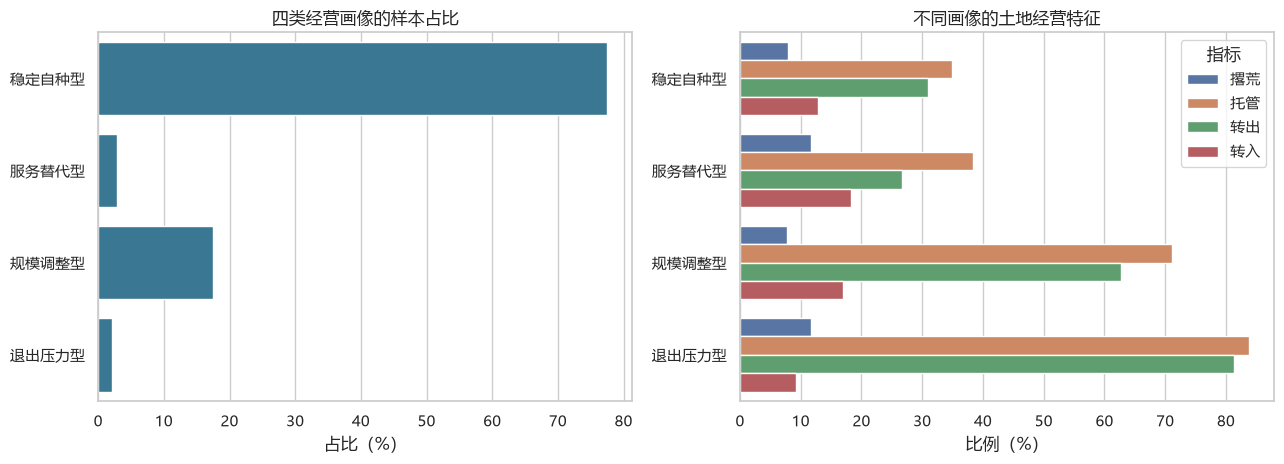

In [8]:
profiles = pd.read_csv(RESULT_DIR / "2025年画像汇总.csv")
profile_meta = json.loads((RESULT_DIR / "2025年画像聚类元数据.json").read_text(encoding="utf-8"))
profile_columns = [
    "profile", "n", "share_percent", "labor", "operated_area", "grain_area",
    "fallow_percent", "managed_percent", "transfer_out_percent", "transfer_in_percent",
]
display(profiles[profile_columns].style.format({column: "{:.2f}" for column in profile_columns if column not in {"profile", "n"}}))
display(pd.Series(profile_meta, name="值").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.barplot(data=profiles, x="share_percent", y="profile", color="#2C7DA0", ax=axes[0])
axes[0].set(title="四类经营画像的样本占比", xlabel="占比（%）", ylabel="")
profile_rates = profiles.melt(
    id_vars="profile", value_vars=["fallow_percent", "managed_percent", "transfer_out_percent", "transfer_in_percent"],
    var_name="指标", value_name="比例",
)
rate_names = {
    "fallow_percent": "撂荒", "managed_percent": "托管",
    "transfer_out_percent": "转出", "transfer_in_percent": "转入",
}
profile_rates["指标"] = profile_rates["指标"].map(rate_names)
sns.barplot(data=profile_rates, x="比例", y="profile", hue="指标", ax=axes[1])
axes[1].set(title="不同画像的土地经营特征", xlabel="比例（%）", ylabel="")
plt.tight_layout()
plt.show()

## 8. 2026 年农户端指标

农户端结果同时给出主口径与排除短时答卷后的敏感性口径。百分比均由相应的成功数除以有效分母计算，而不是统一除以 570。

,label,n,success,percent,denominator_rule,sensitivity_n,sensitivity_success,sensitivity_percent,主口径复算,敏感性复算
0,政策完全清楚,560,141,25.18%,核心有效且政策认知题非空,485,123,25.36%,25.18%,25.36%
1,接受过政策宣讲,560,411,73.39%,核心有效且宣传题非空,485,350,72.16%,73.39%,72.16%
2,流转者全部签正式合同,229,79,34.50%,核心有效、流转面积>0、合同题非空，并排除流转面积及经营模式矛盾,194,66,34.02%,34.50%,34.02%
3,至少使用部分托管,561,342,60.96%,核心有效且托管题非空,486,293,60.29%,60.96%,60.29%
4,未来维持现有规模,560,249,44.46%,核心有效且未来规划题非空,485,214,44.12%,44.46%,44.12%
5,未来扩大粮食种植,560,101,18.04%,核心有效且未来规划题非空,485,83,17.11%,18.04%,17.11%
6,未来逐步转出土地,560,143,25.54%,核心有效且未来规划题非空,485,125,25.77%,25.54%,25.77%
7,未来全部转出不再种粮,560,67,11.96%,核心有效且未来规划题非空,485,63,12.99%,11.96%,12.99%
8,增收约束:化肥农药等农资涨价,562,504,89.68%,核心有效且该多选题非空；短时答卷仅作敏感性排除,487,437,89.73%,89.68%,89.73%
9,增收约束:粮食收购价格偏低,562,490,87.19%,核心有效且该多选题非空；短时答卷仅作敏感性排除,487,422,86.65%,87.19%,86.65%


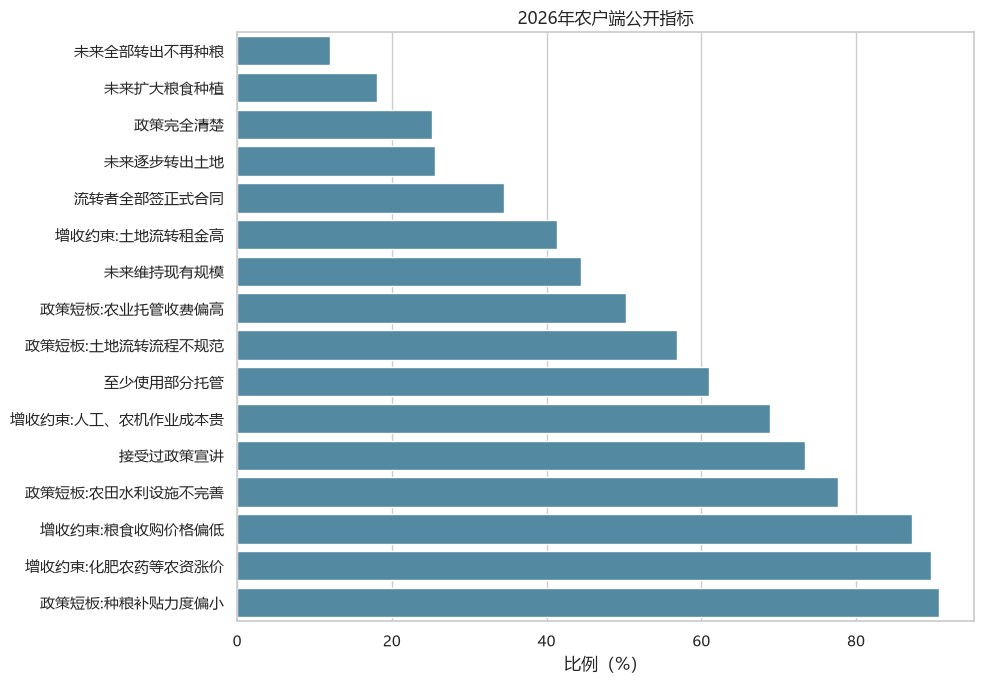

In [9]:
household = pd.read_csv(RESULT_DIR / "2026年农户指标.csv")
household["主口径复算"] = (household["success"] / household["n"] * 100).round(2)
household["敏感性复算"] = (household["sensitivity_success"] / household["sensitivity_n"] * 100).round(2)
display(household.style.format({"percent": "{:.2f}%", "sensitivity_percent": "{:.2f}%", "主口径复算": "{:.2f}%", "敏感性复算": "{:.2f}%"}))

fig, ax = plt.subplots(figsize=(10, 7))
plot_household = household.sort_values("percent")
sns.barplot(data=plot_household, x="percent", y="label", color="#468FAF", ax=ax)
ax.set(title="2026年农户端公开指标", xlabel="比例（%）", ylabel="")
plt.tight_layout()
plt.show()

## 9. 2026 年村级指标

村级指标以有效村级问卷为分母，是对村级治理和服务能力的描述。村级样本量较小，结果应结合分母阅读，不作总体因果推断。

,label,n,success,percent,denominator_rule,sensitivity_n,sensitivity_success,sensitivity_percent,主口径复算,敏感性复算
0,二轮延包全部完成,37,18,48.65%,核心有效且延包进度题非空,33,15,45.45%,48.65%,45.45%
1,统一使用规范合同模板,35,15,42.86%,核心有效、合同题非空，并排除流转面积矛盾,31,12,38.71%,42.86%,38.71%
2,托管服务全覆盖,36,8,22.22%,核心有效且托管覆盖题非空,33,7,21.21%,22.22%,21.21%
3,约束包含土地细碎化,37,28,75.68%,核心有效且村级约束题非空,33,26,78.79%,75.68%,78.79%
4,约束包含水利或机耕路不足,37,22,59.46%,核心有效且村级约束题非空,33,19,57.58%,59.46%,57.58%
5,按季度开展农技或政策宣讲,37,15,40.54%,核心有效且村级宣讲题非空,33,14,42.42%,40.54%,42.42%
6,村级服务短板:农技人员不足,37,25,67.57%,核心有效且该多选题非空；短时答卷仅作敏感性排除,33,21,63.64%,67.57%,63.64%
7,村级服务短板:托管服务供给不足,37,23,62.16%,核心有效且该多选题非空；短时答卷仅作敏感性排除,33,20,60.61%,62.16%,60.61%
8,村级服务短板:民情诉求反馈渠道不畅,37,19,51.35%,核心有效且该多选题非空；短时答卷仅作敏感性排除,33,16,48.48%,51.35%,48.48%
9,村级服务短板:缺少土地流转服务窗口,37,19,51.35%,核心有效且该多选题非空；短时答卷仅作敏感性排除,33,17,51.52%,51.35%,51.52%


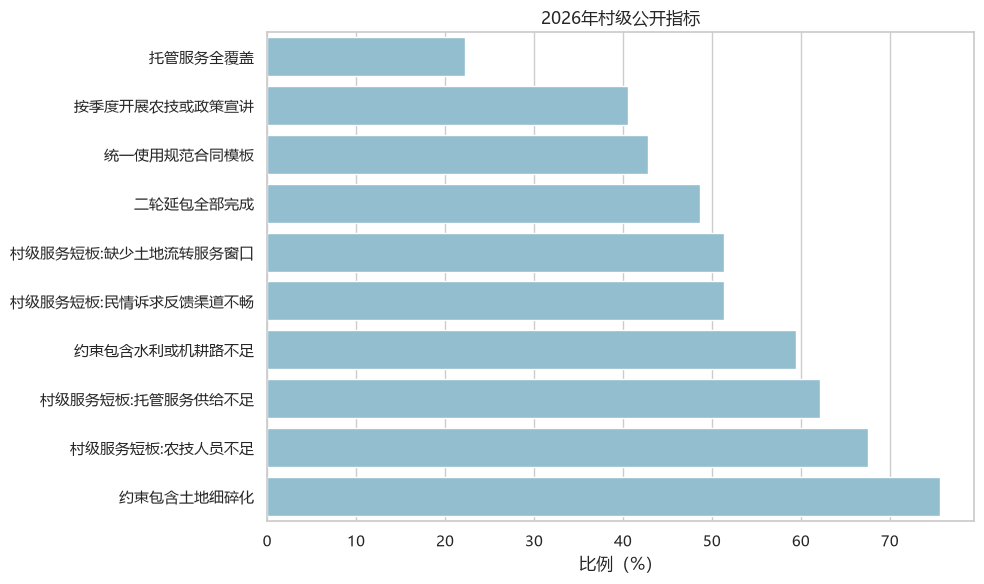

In [10]:
village = pd.read_csv(RESULT_DIR / "2026年村级指标.csv")
village["主口径复算"] = (village["success"] / village["n"] * 100).round(2)
village["敏感性复算"] = (village["sensitivity_success"] / village["sensitivity_n"] * 100).round(2)
display(village.style.format({"percent": "{:.2f}%", "sensitivity_percent": "{:.2f}%", "主口径复算": "{:.2f}%", "敏感性复算": "{:.2f}%"}))

fig, ax = plt.subplots(figsize=(10, 6))
plot_village = village.sort_values("percent")
sns.barplot(data=plot_village, x="percent", y="label", color="#89C2D9", ax=ax)
ax.set(title="2026年村级公开指标", xlabel="比例（%）", ylabel="")
plt.tight_layout()
plt.show()

## 10. 农户端与村级端并列观察

两端指标不是一一匹配数据。并列图只比较同一主题下不同观察层级的比例，不应被解释为户村匹配、同一对象前后对照或因果识别。

,theme,household_label,household_percent,household_n,village_label,village_percent,village_n
0,政策触达,农户接受过政策宣讲,73.39%,560,村级按季度开展宣讲,40.54%,37
1,合同规范,流转户全部签正式合同,34.50%,229,村级统一合同模板,42.86%,35
2,服务覆盖,农户至少使用部分托管,60.96%,561,村级托管全覆盖,22.22%,36


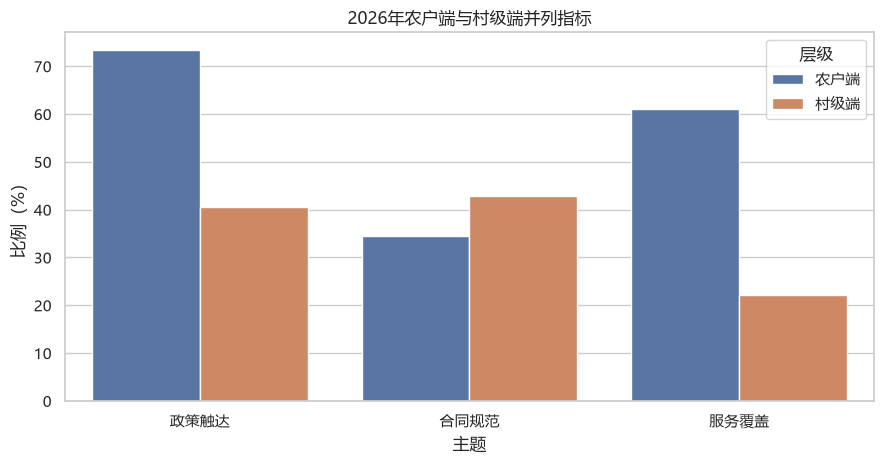

In [11]:
parallel = pd.read_csv(RESULT_DIR / "2026年户村并列指标.csv")
display(parallel.style.format({"household_percent": "{:.2f}%", "village_percent": "{:.2f}%"}))

parallel_long = pd.concat(
    [
        parallel[["theme", "household_percent"]].rename(columns={"household_percent": "比例"}).assign(层级="农户端"),
        parallel[["theme", "village_percent"]].rename(columns={"village_percent": "比例"}).assign(层级="村级端"),
    ],
    ignore_index=True,
)
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=parallel_long, x="theme", y="比例", hue="层级", ax=ax)
ax.set(title="2026年农户端与村级端并列指标", xlabel="主题", ylabel="比例（%）")
plt.tight_layout()
plt.show()

## 11. 图表数据与聚合结果的一致性核对

公开仓库同时提供聚合分析结果和制图数据。以下检查验证核心制图表是否与对应结果表一致，并复算 2026 年全部比例。

In [12]:
figure_prediction = pd.read_csv(FIGURE_DATA_DIR / "fig4-4_area_disaster_prediction.csv").rename(
    columns={"category": "disaster", "value": "predicted_fallow_percent"}
)
prediction_sorted = prediction.sort_values(["disaster", "operated_area_mu"]).reset_index(drop=True)
figure_prediction_sorted = figure_prediction.sort_values(["disaster", "operated_area_mu"]).reset_index(drop=True)

model_figure = pd.read_csv(FIGURE_DATA_DIR / "fig4-3_logit_or.csv")
model_expected = model_view.rename(columns={"term": "category"})[
    ["category", "odds_ratio", "ci_low_or", "ci_high_or", "n"]
].sort_values("category").reset_index(drop=True)
model_figure_sorted = model_figure.sort_values("category").reset_index(drop=True)

profile_figure = pd.read_csv(FIGURE_DATA_DIR / "fig5-3_profile_metrics.csv")
profile_expected = profiles[profile_figure.columns].sort_values("cluster").reset_index(drop=True)
profile_figure_sorted = profile_figure.sort_values("cluster").reset_index(drop=True)

checks = {
    "公开数据文件数为24": len(data_files) == 24,
    "2025土地状态最大有效分母为2079": int(land_status["n"].max()) == 2079,
    "2025撂荒模型有效样本为2055": fallow_model["n"].nunique() == 1 and int(fallow_model["n"].iloc[0]) == 2055,
    "敏感性检验状态全部PASS": sensitivity["status"].eq("PASS").all(),
    "四类画像占比合计为100%": np.isclose(profiles["share_percent"].sum(), 100.0),
    "预测情景制图数据一致": np.allclose(
        prediction_sorted[["operated_area_mu", "predicted_fallow_percent"]],
        figure_prediction_sorted[["operated_area_mu", "predicted_fallow_percent"]],
    ) and prediction_sorted["disaster"].equals(figure_prediction_sorted["disaster"]),
    "模型森林图数据一致": model_expected["category"].equals(model_figure_sorted["category"])
    and np.allclose(model_expected.drop(columns="category"), model_figure_sorted.drop(columns="category")),
    "画像制图数据一致": profile_expected["profile"].equals(profile_figure_sorted["profile"])
    and np.allclose(
        profile_expected.drop(columns="profile"),
        profile_figure_sorted.drop(columns="profile"),
    ),
    "2026农户端比例复算一致": np.allclose(household["percent"], household["主口径复算"], atol=0.011)
    and np.allclose(household["sensitivity_percent"], household["敏感性复算"], atol=0.011),
    "2026村级端比例复算一致": np.allclose(village["percent"], village["主口径复算"], atol=0.011)
    and np.allclose(village["sensitivity_percent"], village["敏感性复算"], atol=0.011),
    "直接标识检查通过": not risky_fields and not direct_value_hits,
}
checks_df = pd.Series(checks, name="通过").rename_axis("检查项").to_frame()
display(checks_df)
assert all(checks.values()), checks
print(f"一致性检查：{sum(checks.values())}/{len(checks)} 项通过")

,通过
检查项,
公开数据文件数为24,True
2025土地状态最大有效分母为2079,True
2025撂荒模型有效样本为2055,True
敏感性检验状态全部PASS,True
四类画像占比合计为100%,True
预测情景制图数据一致,True
模型森林图数据一致,True
画像制图数据一致,True
2026农户端比例复算一致,True


一致性检查：11/11 项通过


## 12. 结果摘要与复现边界

1. 2025 年主实证结果显示，不同经营状态和经营画像呈现明显差异；撂荒模型中受灾变量的 OR 高于 1，经营面积变量的 OR 低于 1。这里报告的是条件关联，不作因果解释。
2. 2025 年敏感性口径改变样本范围和效应量，但公开结果表中的检查状态均为 `PASS`。每种结果必须连同其样本数和口径读取。
3. 2026 年农户端显示政策宣讲、合同与托管服务之间仍有层次差异；村级端显示延包、合同模板、托管覆盖和基础设施等组织容量差异。
4. 农户端与村级端只是同主题的并列观察，不能据此建立个体与村庄的一一匹配。
5. 本 Notebook 已核对所有公开研究数据文件，复算 2026 年比例，并验证核心制图数据与聚合结果的一致性。

若研究者需要重新估计个体层模型、重新聚类或审核逐行清洗规则，必须在具备合法授权、隐私保护和数据安全措施的受控环境中使用未公开的微观数据。公开仓库不提供这些数据。